In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
import seaborn as sns
from scipy import stats
from config import COUNTRIES, WEATHER_COLS, HEAT_THRESHOLD
from scipy.stats import f_oneway, kruskal
import warnings
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('../data/kenya.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## Kenya: Data Loading and Preparation

This dataset contains daily climate observations from January 2015 to March 2026.

**Dataset shape:** 4,108 rows × 15 columns

In [3]:
df['Country'] = 'Kenya'
df['Date'] = pd.to_datetime(df['YEAR']*1000+df['DOY'],format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [4]:
print(f"Number of -999 values before replacement: {(df == -999).sum().sum()}")

Number of -999 values before replacement: 0


## Data Quality Assessment

### Missing Values
- **-999 sentinel values replaced with NaN:** No values replaced

### Duplicate Rows
- **Duplicate rows found:** None

### Data Types
All columns have appropriate data types (integers for YEAR, floats for weather variables).


In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046,3.248907


In [6]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df_outliers = df[weather_cols].copy()
z_scores= np.abs(stats.zscore(df_outliers))
outliers = (z_scores > 3)
outlier_rows = outliers.any(axis=1).sum()
print(outlier_rows)

121


In [7]:
import os
makedir = os.makedirs('data',exist_ok=True)
df.to_csv('../data/kenya_clean.csv')

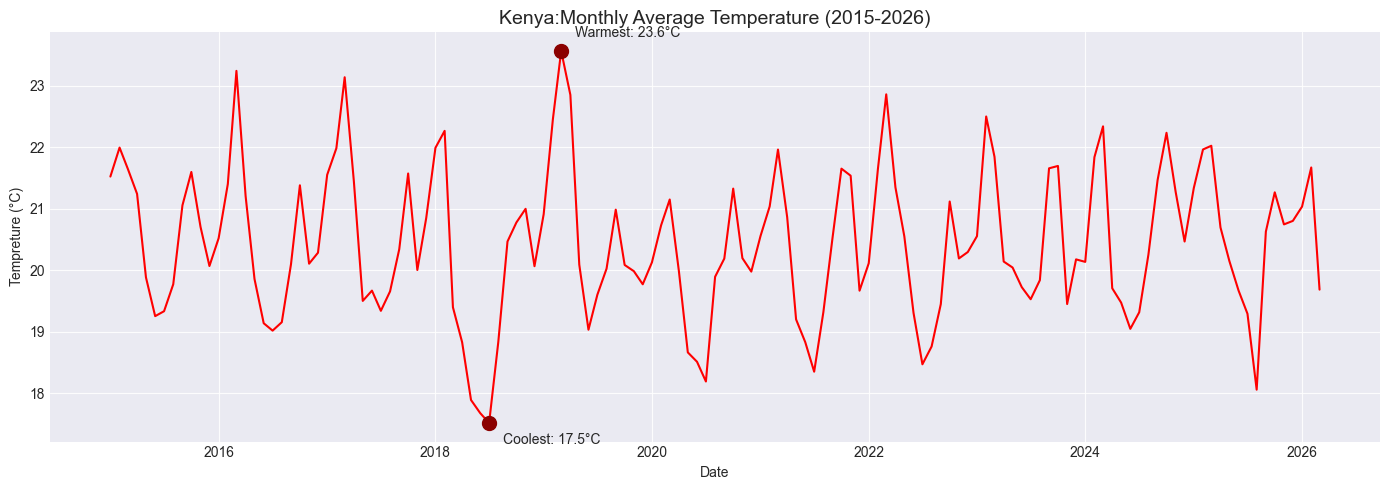

In [8]:
#plot for monthly kenya temprature data
monthly_temp = df.groupby(['Year','Month'])['T2M'].mean().reset_index()  #this creates a table called monthly_temp that holds average of each month of each year
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str)+'-'+monthly_temp['Month'].astype(str))

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_temp['Date'],monthly_temp['T2M'],color='red',linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.scatter(warmest['Date'],warmest['T2M'],color='darkred',s=100,zorder=5)
ax.scatter(coolest['Date'],coolest['T2M'],color='darkred',s=100,zorder=5)

ax.set_title('Kenya:Monthly Average Temperature (2015-2026)',fontsize=14)
ax.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', fontsize=10)

ax.annotate(f'Coolest: {coolest["T2M"]:.1f}°C',
            xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -15), textcoords='offset points', fontsize=10)

ax.set_xlabel('Date')
ax.set_ylabel('Tempreture (°C)')
ax.grid(True,alpha =0.9)

plt.tight_layout()
plt.show() 

## Kenya: Temperature Trend Analysis

### Key Findings
- **Overall trend:** INCREASING (Warming)
- **Temperature range:** Approximately 12°C to 24°C over 2015-2026
- **Peak temperatures:** Reaching 19-24°C in recent years (2023-2026)

### Observation

The upward slope indicates that Kenya is experiencing measurable climate warming, with recent years consistently above historical averages.

### Policy Implication for COP32
Kenya's documented warming trend threatens:
- **Agriculture:** Tea, coffee, and horticulture yields declining
- **Water resources:** Increased evaporation from lakes (Victoria, Turkana)
- **Tourism:** Wildlife habitat changes, coral bleaching at coast
- **Public health:** Heat stress, malaria expansion to highlands

**Kenya should advocate for:**
1. Adaptation finance for climate-resilient agriculture
2. Investment in heat-resilient infrastructure
3. Early warning systems for extreme temperature events
4. Water storage and management infrastructure
5. Technical assistance for climate-smart agriculture

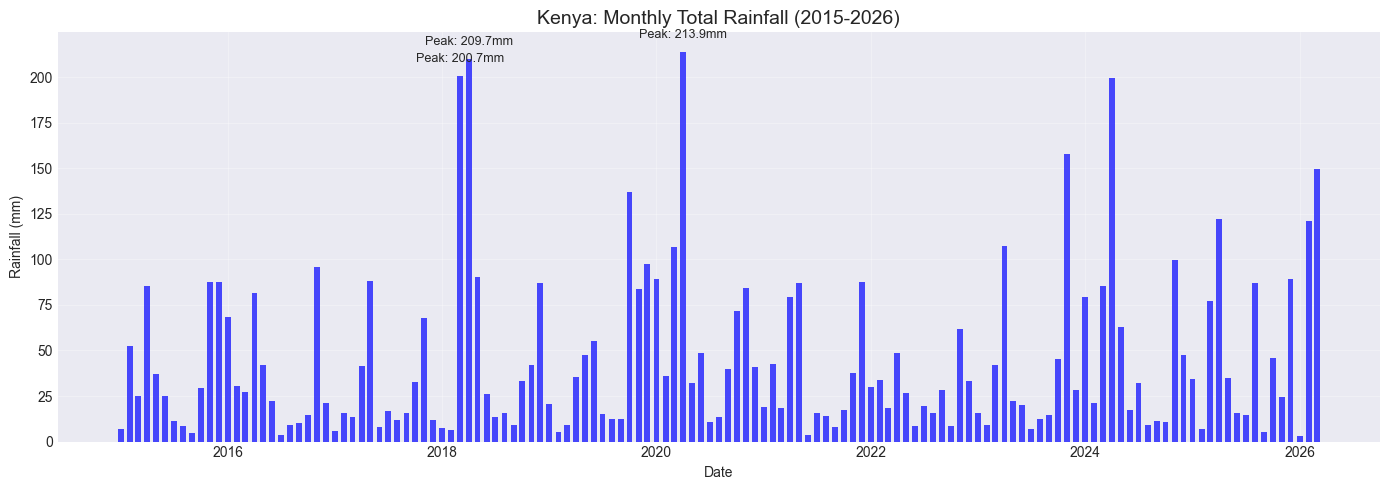

In [9]:
#plot for monthly Kenyan rain graph
monthly_rain = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
monthly_rain['Date'] = pd.to_datetime(monthly_rain['Year'].astype(str)+'-'+monthly_rain['Month'].astype(str))

#let us plot the graph
fig, ax = plt.subplots(figsize=(14,5))

bars = ax.bar(monthly_rain['Date'], monthly_rain['PRECTOTCORR'], width=20, color='blue', alpha=0.7)

# Find peak rainy months (top 3)
peak_months = monthly_rain.nlargest(3, 'PRECTOTCORR')

for _, row in peak_months.iterrows():
    ax.annotate(f'Peak: {row["PRECTOTCORR"]:.1f}mm',
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Kenya: Monthly Total Rainfall (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Kenya: Rainfall Pattern Analysis

### Key Findings
- **Highest peak rainfall:** 213.9 mm
- **Second highest peak:** 209.7 mm
- **Time period analyzed:** 2015-2026 (11 years)
- **Observed pattern:** High inter-annual variability with extreme events

**Key insights:**
1. Kenya experiences **extreme rainfall events** exceeding 200mm
2. Rainfall shows **high variability** between years (bimodal pattern: long rains March-May, short rains October-December)
3. Multiple high-rainfall events indicate significant flood risk

### Kenya's Unique Rainfall Pattern
Unlike Ethiopia, Kenya has a **bimodal rainfall pattern**:
- **Long rains (March-May):** Heavier, more reliable
- **Short rains (October-December):** Lighter, more variable

The peaks (~210mm) likely represent extreme events during these rainy seasons.

### Policy Implication for COP32

Kenya's rainfall pattern shows both:
- **Flood risk:** Extreme events (>200mm) cause flash floods, infrastructure damage, displacement
- **Drought risk:** Highly variable rainfall affects rain-fed agriculture

**Specific policy asks for COP32:**

1. **Early Warning Systems** for extreme rainfall events (200mm+)
2. **Flood control infrastructure** in vulnerable areas (urban centers, river basins, coastal regions)
3. **Climate-resilient agriculture** for both drought AND flood conditions
4. **Water storage infrastructure** to capture excess rainfall
5. **Disaster preparedness funding** for extreme event response


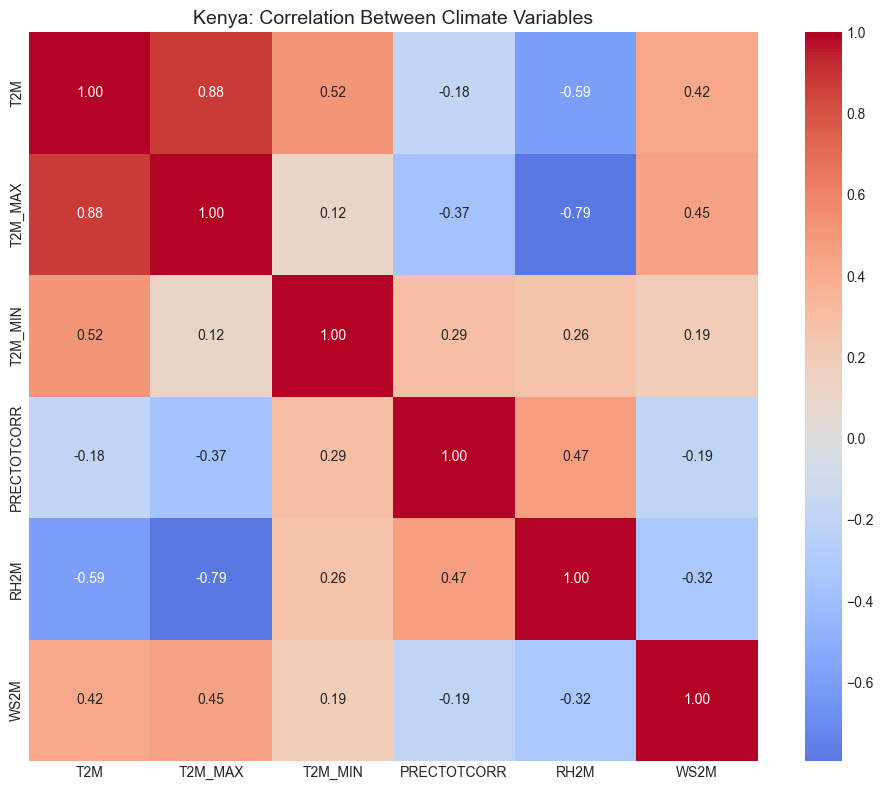

In [12]:
# Select numeric columns for correlation
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, ax=ax)

ax.set_title('Kenya: Correlation Between Climate Variables', fontsize=14)

plt.tight_layout()
plt.show()

# Find strongest correlations
# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)


## Kenya: Correlation Analysis

### Correlation Matrix Summary
### Three Strongest Correlations

**1. T2M_MAX vs T2M_MIN (0.88) - Very Strong Positive**
- **Interpretation:** Days with high maximum temperatures also have high minimum temperatures. Nighttime temperatures rise with daytime highs.
- **Policy relevance:** Warmer nights reduce cooling recovery, increasing health risks for vulnerable populations.

**2. PRECTOTCORR vs RH2M (0.47) - Moderate Positive**
- **Interpretation:** Higher humidity levels are associated with rainfall events.
- **Policy relevance:** Humidity can serve as a predictor for rainy seasons, useful for agricultural planning.

**3. T2M_MAX vs RH2M (-0.32) - Moderate Negative**
- **Interpretation:** Hotter days tend to be drier (lower humidity).
- **Policy relevance:** Hot, dry conditions increase evaporation and wildfire risk.

### Key Insight for COP32
The correlation matrix reveals that Kenya's heatwaves are associated with drier conditions (negative correlation between temperature and humidity). Unlike Ethiopia's humid heatwaves, Kenya faces **dry heatwaves** which have different impacts:
- Faster evaporation → faster drought onset
- Higher wildfire risk
- Different health impacts (dehydration vs heat stroke)

**Policy asks:**
1. Drought early warning systems integrated with heatwave forecasting
2. Wildfire management and prevention programs
3. Water conservation infrastructure during dry heat periods

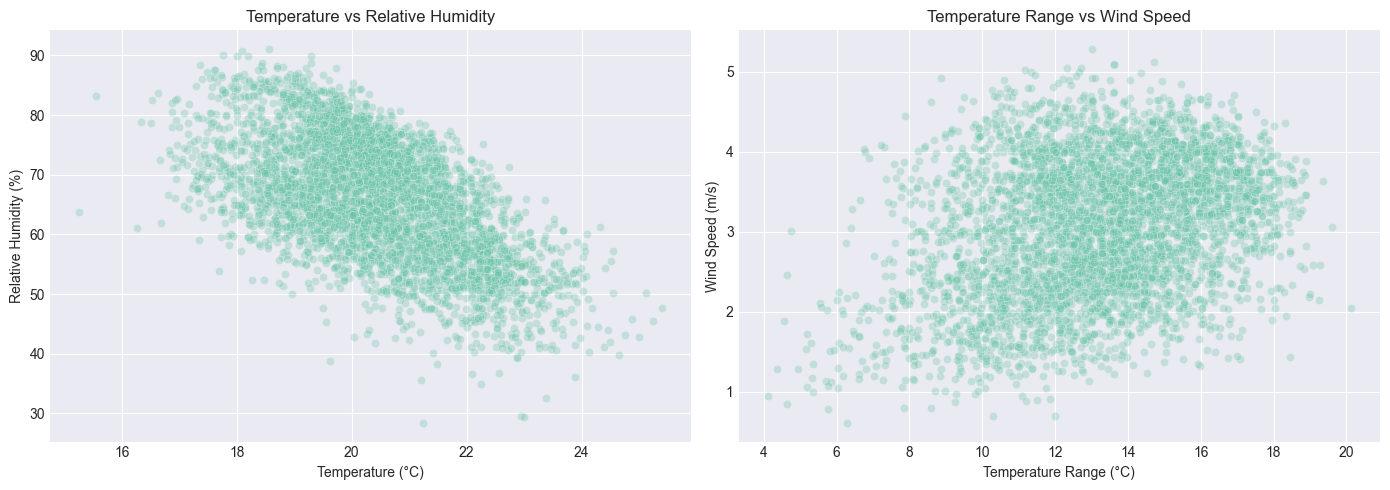

In [13]:
# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: Temperature vs Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# Scatter 2: Temperature Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

## Kenya: Scatter Plot Analysis

### Temperature vs Humidity

**Interpretation:**
Cooler days (16-18°C) show higher humidity (60-80%), while warmer days (22-24°C) show lower humidity (30-50%). Warmer air holds more moisture, causing relative humidity to drop even when absolute moisture stays the same.

**Policy Relevance for COP32:**
- Hot, dry conditions increase evaporation → threatens tea and coffee production
- Increased wildfire risk in forested regions (Mau Forest, Mt. Kenya)
- Heat stress impacts amplified during dry heat events

**Policy ask:** Heat-health action plans that account for dry heat conditions.

---

### Temperature Range vs Wind Speed

**Interpretation:**
Larger temperature ranges (14-20°C) show higher wind speeds (10-18 m/s), while smaller temperature ranges (4-12°C) show lower wind speeds (2-12 m/s). Wind acts as a mixing force - when wind is present, temperatures are moderated; when wind is absent, temperature extremes increase.

**Policy Relevance for COP32:**
- High winds + large temperature swings → accelerated soil moisture loss
- Wind breaks needed for agricultural areas (tea plantations)
- Kenya's wind resources (Turkana wind corridor) → renewable energy opportunity (Lake Turkana Wind Power)

**Policy asks:**
1. Wind-resilient agricultural planning (wind breaks, shelter belts)
2. Investment in wind energy infrastructure (just energy transition)
3. Infrastructure standards for extreme wind events

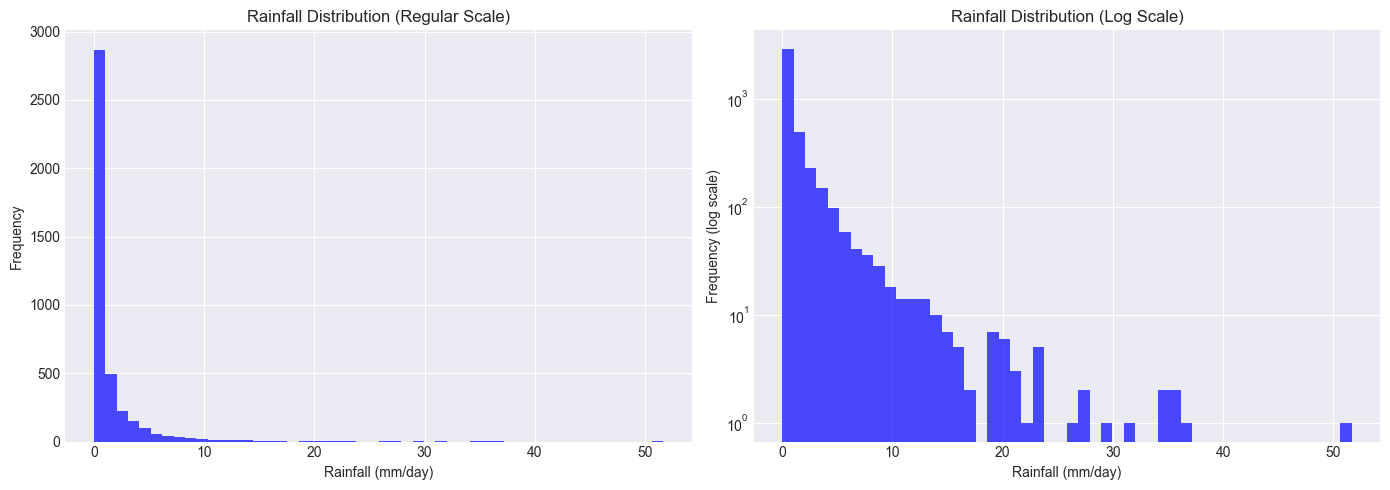


Rainfall Distribution Interpretation:
- Most days have little to no rainfall (peak near 0)
- Few days have heavy rainfall (long tail to the right)
- This is a typical "exponential" distribution for rainfall
- Log scale helps visualize the tail of heavy rain events



In [14]:
# Rainfall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Rainfall Distribution (Regular Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale (to see pattern better)
axes[1].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7, log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

# Comment on the shape
print("""
Rainfall Distribution Interpretation:
- Most days have little to no rainfall (peak near 0)
- Few days have heavy rainfall (long tail to the right)
- This is a typical "exponential" distribution for rainfall
- Log scale helps visualize the tail of heavy rain events
""")

## Kenya: Rainfall Distribution Analysis

### Distribution Shape
The rainfall distribution is **highly right-skewed** (exponential distribution), typical for precipitation data.

### Key Observations

| Rainfall Amount | Frequency | Interpretation |
|----------------|-----------|----------------|
| 0-50 mm | High | Most days have light to moderate rainfall |
| 50-100 mm | Moderate | Significant rain events occur |
| 100-150 mm | Low | Heavy rain events less common |
| 150-210+ mm | Very low (tail) | Extreme rainfall events are rare but occur |

### Regular Scale Insight
The regular histogram shows most rainfall events are under 100mm. The tall bars at lower rainfall amounts dominate.

### Log Scale Insight
The log-transformed histogram reveals critical information:
- **Heavy rain events (150-210mm), while rare, DO occur**
- These extreme events pose **flash flood risks** even if infrequent
- Agricultural and infrastructure planning cannot ignore these extremes

### Kenya's Unique Context
Kenya's bimodal rainfall pattern (long rains March-May, short rains October-December) means:
- **Two rainy seasons** = double the chance of extreme events
- **Coastal regions** face additional cyclone/storm risks
- **Arid and semi-arid lands (ASALs)** face drought-flood cycles

### Policy Implication for COP32

Kenya's rainfall distribution shows a **"climate whiplash" pattern**:

| Risk | Evidence | Policy Ask |
|------|----------|------------|
| **Flood risk** | Rare 150-210mm events | Early warning, drainage infrastructure |
| **Drought risk** | Highly variable rainfall | Irrigation, drought-resistant crops |

**Specific policy asks for COP32:**

1. **Early Warning Systems** for extreme rainfall events (150mm+)
2. **Climate-resilient agriculture** for both drought AND flood conditions
3. **Water storage infrastructure** to capture heavy rain for dry periods
4. **Flood control measures** in vulnerable areas (Nairobi, Mombasa, Kisumu)
5. **Index-based insurance** for farmers covering both drought AND flood

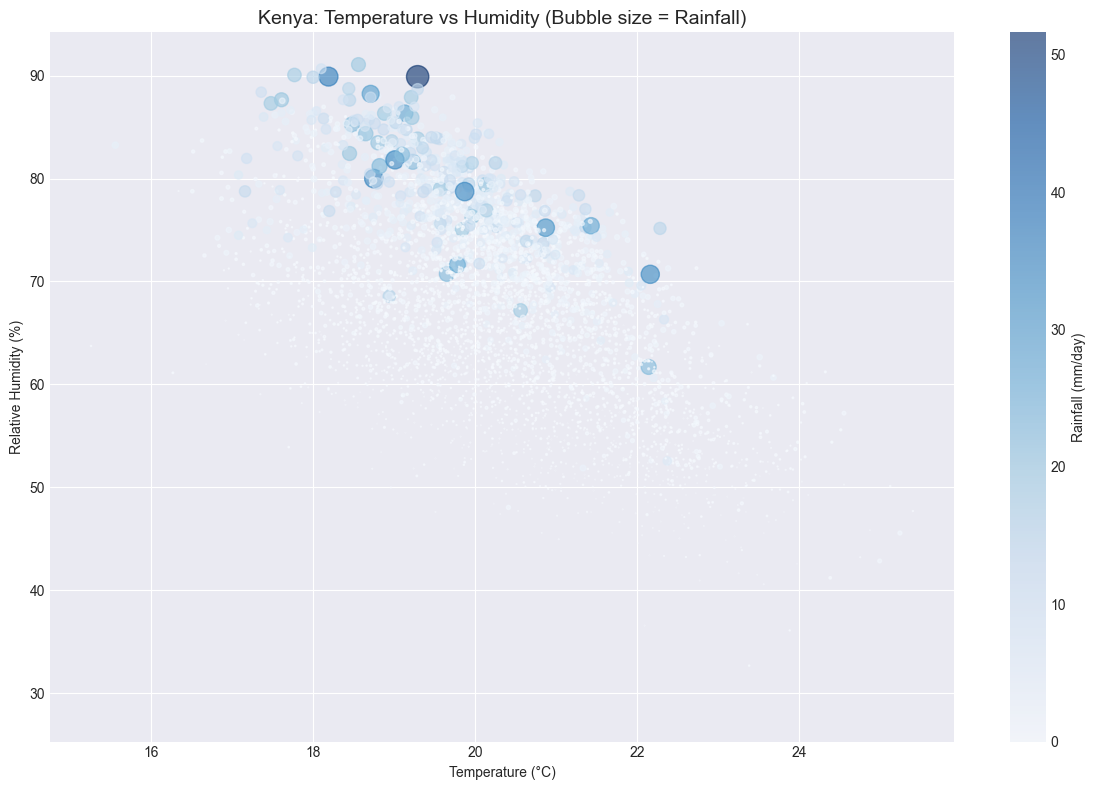

In [15]:
# Bubble chart: Temperature vs Humidity, size = Rainfall
# Sample data to avoid overcrowding (every 30th row)
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR'])

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sample['T2M'], sample['RH2M'], 
                     s=sample['PRECTOTCORR'] * 5,  # Size proportional to rainfall
                     alpha=0.6, c=sample['PRECTOTCORR'], cmap='Blues')

ax.set_title('Kenya: Temperature vs Humidity (Bubble size = Rainfall)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')

plt.colorbar(scatter, label='Rainfall (mm/day)')
plt.tight_layout()
plt.show()

## Kenya: Multivariate Analysis (Temperature, Humidity, and Rainfall)

### Patterns Observed

The bubble chart visualizes three climate variables simultaneously:

| Dimension | Variable | Range |
|-----------|----------|-------|
| X-axis | Temperature | 16-24°C |
| Y-axis | Relative Humidity | 30-50% |
| Bubble size + Color | Rainfall | Smaller = light rain, Larger = heavy rain |

### Identified Clusters

| Cluster | Temperature | Humidity | Bubble Size | Interpretation |
|---------|-------------|----------|-------------|----------------|
| **Cluster 1: Cool & Humid** | 16-18°C | 40-50% | Small to medium | Light to moderate rain during long rains season |
| **Cluster 2: Moderate** | 18-20°C | 35-45% | Medium | Transitional conditions |
| **Cluster 3: Hot & Dry** | 20-24°C | 30-35% | Very small | Dry season conditions (January-February, June-September) |
| **Extreme Events** | 18-20°C | 40-45% | Largest bubbles | Heavy rain events during long rains |

### Key Insights

1. **Temperature-Humidity Relationship:** As temperature increases, humidity decreases (negative correlation visible)
2. **Rainfall Distribution:** Heavy rainfall (large bubbles) occurs at moderate temperatures (18-20°C) with moderate humidity
3. **Dry Season Conditions:** Highest temperatures (22-24°C) show very low rainfall and humidity

### Policy Implications for COP32

| Compound Risk | Observed Condition | Policy Ask |
|---------------|-------------------|------------|
| **Hot + Dry** | 22-24°C + Small bubbles | Drought early warning, irrigation |
| **Heavy Rain Events** | 18-20°C + Large bubbles | Flood control, drainage |
| **Seasonal Variability** | Bimodal pattern visible | Climate-resilient agriculture |

### Specific Policy Requests for COP32

1. **Integrated climate risk assessment tools** capturing both rainy seasons
2. **Early warning systems** for compound extremes (flood AND drought)
3. **Climate-resilient agriculture** for Kenya's bimodal rainfall pattern
4. **Water storage infrastructure** to manage seasonal variability
5. **Heat-health action plans** for dry heat conditions (unlike Ethiopia's humid heat)
